Goal:

Not “who has higher accuracy”, but <br>
who breaks first when the data changes.

##### Same as before (collapse)

In [65]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets

transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="data",
    train=True,
    transform=transform,
    download=False
)

test_data = datasets.MNIST(
    root="data",
    download=False,
    transform=transform,
    train=False
)

In [66]:
linear_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

cnn_model = nn.Sequential(
    nn.Conv2d(1, 8, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(8 * 13 * 13, 10)
)

In [67]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [68]:
loss_fn = nn.CrossEntropyLoss()
epochs = 3

def train_model(model):
    print(f"Model: {model} \n")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        model.train()
        
        for images, labels in train_loader:
            preds = model(images)
            loss = loss_fn(preds, labels)
            
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
        print(f"Epoch: {epoch} | Loss: {loss.item():.4f}")
        
        
def test_model(model):
    total = 0
    correct = 0
    
    with torch.no_grad():
        model.eval()
        
        for images, labels in test_loader:
            preds = model(images)
            predicted = preds.argmax(dim=1)
            
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
    accuracy = correct / total
    print(accuracy, "\n")

In [ ]:
train_model(linear_model)
test_model(linear_model)

train_model(cnn_model)
test_model(cnn_model)   

Model: Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
) 

Epoch: 0 | Loss: 0.1672
Epoch: 1 | Loss: 0.0698
Epoch: 2 | Loss: 0.1820
0.968 

Model: Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=1352, out_features=10, bias=True)
) 

Epoch: 0 | Loss: 0.5872
Epoch: 1 | Loss: 0.1697
Epoch: 2 | Loss: 0.0437
0.9662 



### Step 1. Find mistakes

We don’t look at averages first. <br>
We look at failures.

In [70]:
cnn_model.eval()

wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        preds = cnn_model(images)
        predicted = preds.argmax(dim=1)
        
        mask = predicted != labels
        if mask.any():
            wrong_images.append(images[mask])
            wrong_preds.append(predicted[mask])
            wrong_labels.append(labels[mask])
            
        if len(wrong_images) > 0:
            break

#### What mask is

- a boolean tensor

- True where the model was wrong

- False where it was correct

Example:

`predicted = [3, 7, 1, 0]` <br>
`labels    = [3, 2, 1, 0]`

`mask = [False, True, False, False]`


Only 1 mistake here.

### Step 2. Visualize what the CNN gets wrong

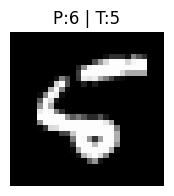

In [71]:
imgs = wrong_images[0]
preds = wrong_preds[0]
labels = wrong_labels[0]

n = len(imgs)          # how many mistakes exist
n = min(n, 5)          # show at most 5

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
if n == 1:
    axes = [axes]
    
for i in range(n):
    axes[i].imshow(imgs[i].squeeze(), cmap="gray")
    axes[i].set_title(f"P:{preds[i].item()} | T:{labels[i].item()}")
    axes[i].axis("off")
plt.show()

### Step 3. Introduce a small real-world change

Shift images by 2 pixels

In [72]:
import torch.nn.functional as F

def shift_right(images, pixels=3):
    return F.pad(images, (pixels, 0, 0, 0))[:, :, :, :-pixels]


This is tiny. <br>
Humans barely notice.

### Step 4. Compare Linear vs CNN on shifted data

In [73]:
def test_model_on_shifted_data(model, loader, shift_fn):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            shifted = shift_fn(images)
            preds = model(shifted)
            predicted = preds.argmax(dim=1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return correct / total


In [76]:
print("Linear Clean: ")
test_model(linear_model)
print("CNN Clean: ")
test_model(cnn_model)

shifted_linear = test_model_on_shifted_data(
    linear_model, test_loader, shift_right
)

shifted_cnn = test_model_on_shifted_data(
    cnn_model, test_loader, shift_right
)

print("Linear shifted: \n", shifted_linear, "\n")
print("CNN shifted: \n", shifted_cnn)


Linear Clean: 
0.968 

CNN Clean: 
0.9662 

Linear shifted: 
 0.5126 

CNN shifted: 
 0.6697
